In [3]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd

# Phenol derivative dataset
molecules = {
    "Phenol": "Oc1ccccc1",
    "p-Cresol": "CC1=CC=C(C=C1)O",
    "Catechol": "Oc1cccc(O)c1",
    "Anisole": "COc1ccccc1",
    "p-Nitrophenol": "O=[N+]([O-])c1ccc(O)cc1"
}

# Store results
results = []

for name, smiles in molecules.items():

    mol = Chem.MolFromSmiles(smiles)

    results.append({
        "Molecule": name,
        "SMILES": Chem.MolToSmiles(mol),
        "MW": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "Rotatable_Bonds": Descriptors.NumRotatableBonds(mol),
        "Ring_Count": Descriptors.RingCount(mol)
    })

# Create DataFrame
df = pd.DataFrame(results)

df

,Molecule,SMILES,MW,LogP,TPSA,HBD,HBA,Rotatable_Bonds,Ring_Count
0,Phenol,Oc1ccccc1,94.113,1.39220,20.23,1,1,0,1
1,p-Cresol,Cc1ccc(O)cc1,108.140,1.70062,20.23,1,1,0,1
2,Catechol,Oc1cccc(O)c1,110.112,1.09780,40.46,2,2,0,1
3,Anisole,COc1ccccc1,108.140,1.69520,9.23,0,1,1,1
4,p-Nitrophenol,O=[N+]([O-])c1ccc(O)cc1,139.110,1.30040,63.37,1,3,1,1


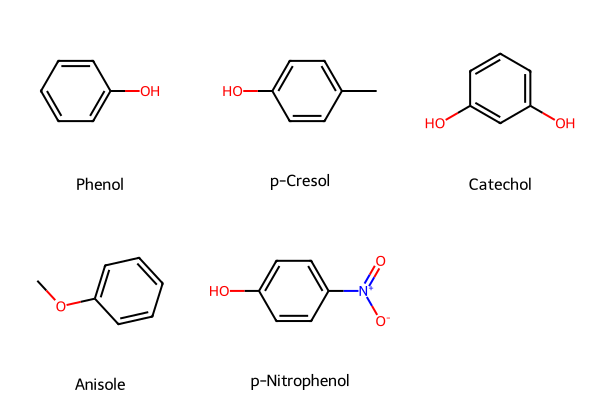

In [4]:
from rdkit.Chem import Draw

mols = [
    Chem.MolFromSmiles(smiles)
    for smiles in molecules.values()
]

Draw.MolsToGridImage(
    mols,
    legends=list(molecules.keys()),
    molsPerRow=3
)

In [ ]:
import matplotlib.pyplot as plt

plt.bar(df["Molecule"], df["LogP"])
plt.xlabel("Molecule")
plt.ylabel("LogP")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
df.to_csv("phenol_derivatives_descriptors.csv", index=False)

print("CSV saved successfully")

CSV saved successfully


In [7]:
df[["Molecule", "MW", "LogP", "TPSA", "HBD", "HBA"]]

,Molecule,MW,LogP,TPSA,HBD,HBA
0,Phenol,94.113,1.39220,20.23,1,1
1,p-Cresol,108.140,1.70062,20.23,1,1
2,Catechol,110.112,1.09780,40.46,2,2
3,Anisole,108.140,1.69520,9.23,0,1
4,p-Nitrophenol,139.110,1.30040,63.37,1,3


In [8]:
df.to_csv("phenol_derivatives_descriptors.csv", index=False)

print("Dataset saved.")

Dataset saved.


In [9]:
from rdkit import Chem
from rdkit.Chem import AllChem

phenol = Chem.MolFromSmiles("Oc1ccccc1")
p_cresol = Chem.MolFromSmiles("Cc1ccc(O)cc1")
catechol = Chem.MolFromSmiles("Oc1ccccc1O")
p_nitrophenol = Chem.MolFromSmiles("Oc1ccc([N+](=O)[O-])cc1")

molecules = {
    "Phenol": phenol,
    "p-Cresol": p_cresol,
    "Catechol": catechol,
    "p-Nitrophenol": p_nitrophenol
}

print("Molecules loaded:", list(molecules.keys()))

Molecules loaded: ['Phenol', 'p-Cresol', 'Catechol', 'p-Nitrophenol']


In [10]:
for name, mol in molecules.items():
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.UFFOptimizeMolecule(mol)
    molecules[name] = mol

print("3D structures generated and optimized.")

3D structures generated and optimized.


In [11]:
for name, mol in molecules.items():
    print(name, "→", mol.GetNumAtoms(), "atoms")

Phenol → 13 atoms
p-Cresol → 16 atoms
Catechol → 14 atoms
p-Nitrophenol → 15 atoms


Phenol


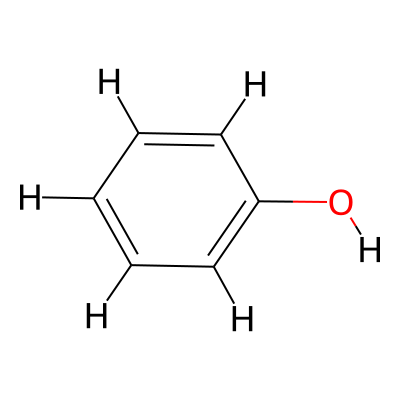

p-Cresol


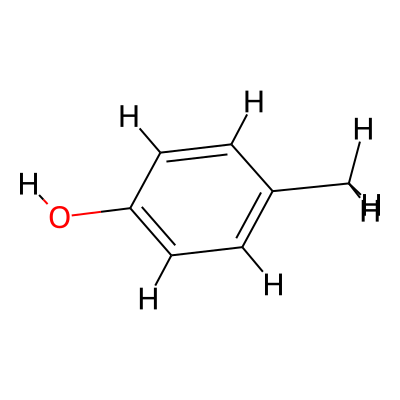

Catechol


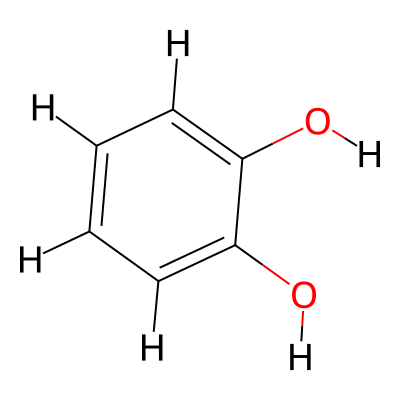

p-Nitrophenol


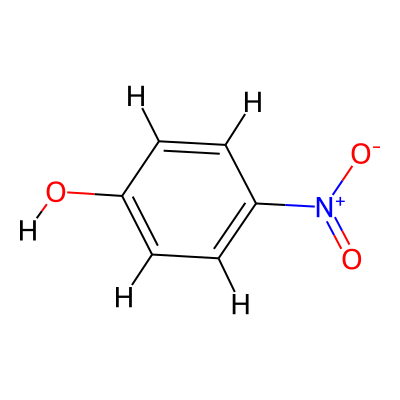

In [12]:
from rdkit.Chem import Draw

for name, mol in molecules.items():
    print(name)
    display(Draw.MolToImage(mol, size=(400, 400)))

In [13]:
from rdkit.Chem import rdMolTransforms

for name, mol in molecules.items():
    conf = mol.GetConformer()
    print(name)
    for i in range(min(3, mol.GetNumAtoms())):
        pos = conf.GetAtomPosition(i)
        print(i, round(pos.x, 3), round(pos.y, 3), round(pos.z, 3))

Phenol
0 2.51 0.026 -0.183
1 1.122 0.039 -0.07
2 0.36 -1.066 -0.478
p-Cresol
0 2.48 0.236 -0.051
1 0.988 0.085 -0.063
2 0.179 1.002 0.626
Catechol
0 1.815 -1.471 -0.357
1 0.698 -0.668 -0.135
2 -0.548 -1.252 0.14
p-Nitrophenol
0 -3.035 0.23 -0.094
1 -1.646 0.139 -0.054
2 -0.872 1.287 -0.248


In [14]:
from rdkit.Chem import SDWriter

for name, mol in molecules.items():
    filename = name.replace("-", "_").replace(" ", "_") + ".sdf"
    
    writer = SDWriter(filename)
    writer.write(mol)
    writer.close()

    print("Saved:", filename)

Saved: Phenol.sdf
Saved: p_Cresol.sdf
Saved: Catechol.sdf
Saved: p_Nitrophenol.sdf
